Repairable System Test 1: Sampling System Repair Time

(array([1., 4., 2., 2., 1.]),
 array([32.55801695, 35.96127069, 39.36452444, 42.76777819, 46.17103194,
        49.57428569]),
 <BarContainer object of 5 artists>)

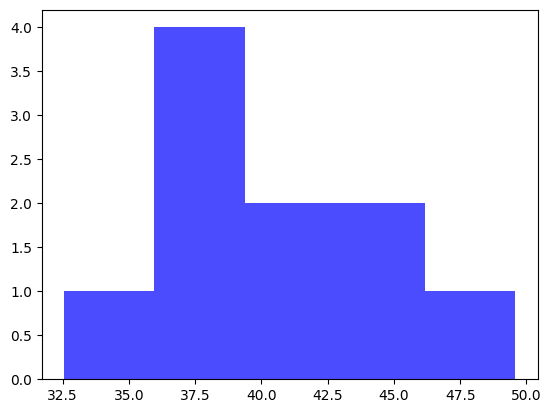

In [4]:
from system_objects.series_system import SeriesSystem
# from system_objects.parallel_system import ParallelSystem
from component_objects.component_weibull import WeibullComponent
import numpy as np
import matplotlib.pyplot as plt

# initialize a series system of 3 components 

comp1 = WeibullComponent(name="Comp1", shape=2.0, MTTF=1000.0, MTTR=50.0)
comp2 = WeibullComponent(name="Comp2", shape=2.0, MTTF=1000.0, MTTR=50.0)
comp3 = WeibullComponent(name="Comp3", shape=2.0, MTTF=1000.0, MTTR=50.0)

series_system = SeriesSystem(
    name="SeriesSystem",
    components=[comp1, comp2, comp3]
)

# simulate n repairs and plot the repair times
n_repairs = 10
repair_times = []
for _ in range(n_repairs):
    repair_time, __ = series_system.repair()
    repair_times.append(repair_time)

plt.hist(repair_times, bins=5, alpha=0.7, color='blue')

Repairable System Test 1: Plotting System History with Repairs

In [1]:
from system_objects.series_system import SeriesSystem
from component_objects.component_weibull import WeibullComponent

# initalize a series system
comps = [WeibullComponent(name= f"Comp#{i+1}", MTTF=200, MTTR=20, shape=1.5) for i in range(3)]
system = SeriesSystem("Repairable Series System",components=comps)

# simulate the system over time with repairs 
sim_duration = 1000  # total time to simulate
system.simulate(sim_duration, repairable=True)

# plot the system state history over time
system.plot_history()

ValueError: Length of values (1017) does not match length of index (1045)

In [ ]:
import math
gamma_value_int = math.gamma(5)


SERIES SYSTEM OF EXPONENTIAL COMPS

In [ ]:
from sympy import Symbol, integrate
from system_objects.series_system import SeriesSystem
from component_objects.component_exponential import ExponentialComponent 

import matplotlib.pyplot as plt
import numpy as np

# initialize exponential comps
num_comps = 3
MTTF = [10 for _ in range(num_comps)]
# MTTF[0] = 20
comps = [ExponentialComponent(name="f{i+1}", MTTF= MTTF[i], MTTR=1) for i in range(num_comps)]

# initialize a system with the comps 
sys = SeriesSystem("test_series_sys", comps)

# plotting settings
t = np.arange(1, 101, 1)   # <-- 1D array
shapes = ['.', '|', '_', 'd']
colors = ['b', 'g', 'y', 'k']

# plot the analytical z_s for each component and the system 
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.z_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$z_{i}(t)$")
plt.plot(t, sys.z_s(t), color=colors[-1], marker = shapes[-1], label= r"$z_{sys}(t)$")
plt.title("Exponential Series System Failure Rates (z(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.R_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$R_{i}(t)$")
plt.plot(t, sys.R_s(t), color=colors[-1], marker = shapes[-1], label= r"$R_{sys}(t)$")
plt.title("Exponential Series System Reliability over Time (R(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.f_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$f_{i}(t)$")
plt.plot(t, sys.f_s(t), color=colors[-1], marker = shapes[-1], label= r"$f_{sys}(t)$")
plt.title("Exponential Series System Probability Density (PDF: f(t))")
plt.legend()

#print estimated MTTF
print(f"System expected MTTF is: {sys.MTTF_s}")

BOOK EXAMPLE 6.10

In [ ]:
from math import gamma

mttf = gamma(1/1.8+1)
print(mttf)


In [ ]:
from sympy import Symbol, integrate
from system_objects.parallel_system import ParallelSystem
from component_objects.component_weibull import WeibullComponent 

import matplotlib.pyplot as plt
import numpy as np

# initialize weibull comps
num_comps = 2
MTTF = [mttf for _ in range(num_comps)]
# MTTF[0] = 20
comps = [WeibullComponent(name="f{i+1}", MTTF= MTTF[i], MTTR=1, shape=0.6) for i in range(num_comps)]

# initialize a system with the comps 
sys = ParallelSystem("test_series_sys", comps)

#print estimated MTTF
sys_MTTF = sys.MTTF_s()
print(f"System expected MTTF is: {sys_MTTF:.4f}")

# plotting settings
t = np.arange(0, 3.5, 0.01)   # <-- 1D array
shapes = ['s', '.', '_', 'd']
colors = ['b', 'r', 'g', 'k']

# plot the analytical z_s for each component and the system 
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.z_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$z_{i}(t)$")
plt.plot(t, sys.z_s(t), color=colors[-1], marker = shapes[-1], label= r"$z_{sys}(t)$")
plt.axvline(x=sys_MTTF, color='black', linestyle='--', linewidth=2, label=fr"$MTTF_s ={sys_MTTF:.3f}$")
plt.title("Weibull Series System Failure Rates (z(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.R_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$R_{i}(t)$")
plt.plot(t, sys.R_s(t), color=colors[-1], marker = shapes[-1], label= r"$R_{sys}(t)$")
plt.axvline(x=sys_MTTF, color='black', linestyle='--', linewidth=2, label=fr"$MTTF_s ={sys_MTTF:.3f}$")
plt.title("Weibull Series System Reliability over Time (R(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.f_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$f_{i}(t)$")
plt.plot(t, sys.f_s(t), color=colors[-1], marker = shapes[-1], label= r"$f_{sys}(t)$")
plt.axvline(x=sys_MTTF, color='black', linestyle='--', linewidth=2, label=fr"$MTTF_s ={sys_MTTF:.3f}$")
plt.title("Weibull Series System Probability Density (PDF: f(t))")
plt.legend()

In [ ]:
from sympy import Symbol, integrate
from system_objects.parallel_system import ParallelSystem
from component_objects.component_weibull import WeibullComponent 

import matplotlib.pyplot as plt
import numpy as np

# initialize weibull comps
num_comps = 2
MTTF = [mttf for _ in range(num_comps)]
# MTTF[0] = 20
comps = [WeibullComponent(name="f{i+1}", MTTF= MTTF[i], MTTR=1, shape=1.8) for i in range(num_comps)]

# initialize a system with the comps 
sys = ParallelSystem("test_series_sys", comps)

#print estimated MTTF
sys_MTTF = sys.MTTF_s()
print(f"System expected MTTF is: {sys_MTTF:.4f}")

# plotting settings
t = np.arange(0, 3.5, 0.01)   # <-- 1D array
shapes = ['s', '.', '_', 'd']
colors = ['b', 'r', 'g', 'k']

# plot the analytical z_s for each component and the system 
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.z_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$z_{i}(t)$")
plt.plot(t, sys.z_s(t), color=colors[-1], marker = shapes[-1], label= r"$z_{sys}(t)$")
plt.axvline(x=sys_MTTF, color='black', linestyle='--', linewidth=2, label=fr"$MTTF_s ={sys_MTTF:.3f}$")
plt.title("Weibull Series System Failure Rates (z(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.R_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$R_{i}(t)$")
plt.plot(t, sys.R_s(t), color=colors[-1], marker = shapes[-1], label= r"$R_{sys}(t)$")
plt.axvline(x=sys_MTTF, color='black', linestyle='--', linewidth=2, label=fr"$MTTF_s ={sys_MTTF:.3f}$")
plt.title("Weibull Series System Reliability over Time (R(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.f_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$f_{i}(t)$")
plt.plot(t, sys.f_s(t), color=colors[-1], marker = shapes[-1], label= r"$f_{sys}(t)$")
plt.axvline(x=sys_MTTF, color='black', linestyle='--', linewidth=2, label=fr"$MTTF_s ={sys_MTTF:.3f}$")
plt.title("Weibull Series System Probability Density (PDF: f(t))")
plt.legend()

KooN Exponential System

In [ ]:
from sympy import Symbol, integrate
from system_objects.kooN_system import KOutOfNSystem
from component_objects.component_exponential import ExponentialComponent 

import matplotlib.pyplot as plt
import numpy as np

# initialize exponential comps
num_comps = 3
MTTF = [10 for _ in range(num_comps)]
# MTTF[0] = 20
comps = [ExponentialComponent(name="f{i+1}", MTTF= MTTF[i], MTTR=1) for i in range(num_comps)]

# initialize a system with the comps 
sys = KOutOfNSystem("test_series_sys", comps, k=2)

# plotting settings
t = np.arange(1, 101, 1)   # <-- 1D array
shapes = ['.', '|', '_', 'd']
colors = ['b', 'g', 'y', 'k']

# plot the analytical z_s for each component and the system 
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.z_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$z_{i}(t)$")
plt.plot(t, sys.z_s(t), color=colors[-1], marker = shapes[-1], label= r"$z_{sys}(t)$")
plt.title("Exponential KooN System Failure Rates (z(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.R_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$R_{i}(t)$")
plt.plot(t, sys.R_s(t), color=colors[-1], marker = shapes[-1], label= r"$R_{sys}(t)$")
plt.title("Exponential KooN System Reliability over Time (R(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.f_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$f_{i}(t)$")
plt.plot(t, sys.f_s(t), color=colors[-1], marker = shapes[-1], label= r"$f_{sys}(t)$")
plt.title("Exponential KooN System Probability Density (PDF: f(t))")
plt.legend()

#print estimated MTTF
print(f"System expected MTTF is: {sys.MTTF_s}")

Weibull KooN System

In [ ]:
from sympy import Symbol, integrate
from system_objects.kooN_system import KOutOfNSystem
from component_objects.component_weibull import WeibullComponent 

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# Prepare storage for MTTFs
# ============================================================
MTTF_results = []

# ============================================================
# Create 3 separate figures with 3 subplots each
# ============================================================
fig_z, axes_z = plt.subplots(1, 3, figsize=(15, 4))
fig_R, axes_R = plt.subplots(1, 3, figsize=(15, 4))
fig_f, axes_f = plt.subplots(1, 3, figsize=(15, 4))

t = np.arange(1, 101, 1)
num_comps = 3

shapes = ['.', '|', '_']
colors = ['b', 'g', 'y']


for k in range(1, 4):

    # --------------------------------------------------------
    # initialize Weibull components
    # --------------------------------------------------------
    MTTF_vals = [30 for _ in range(num_comps)]
    comps = [WeibullComponent(name=f"f{i+1}", MTTF=MTTF_vals[i], MTTR=1)
             for i in range(num_comps)]

    # --------------------------------------------------------
    # initialize system
    # --------------------------------------------------------
    sys = KOutOfNSystem("test_KooN_sys", comps, k=k)

    # --------------------------------------------------------
    # subplot indices
    # --------------------------------------------------------
    ax_z = axes_z[k-1]
    ax_R = axes_R[k-1]
    ax_f = axes_f[k-1]

    # ========================================================
    # z(t) subplot
    # ========================================================
    for i, c in enumerate(comps):
        ax_z.plot(t, c.z_t(t), marker=shapes[i], color=colors[i],
                  linestyle='', label=fr"$z_{i+1}(t)$")

    ax_z.plot(t, sys.z_s(t), color='k', label=r"$z_{sys}(t)$")
    ax_z.set_title(fr"K={k}: System Hazard $z_s(t)$")
    ax_z.legend()
    ax_z.grid(True)

    # ========================================================
    # R(t) subplot
    # ========================================================
    for i, c in enumerate(comps):
        ax_R.plot(t, c.R_t(t), marker=shapes[i], color=colors[i],
                  linestyle='', label=fr"$R_{i+1}(t)$")

    ax_R.plot(t, sys.R_s(t), color='k', label=r"$R_{sys}(t)$")
    ax_R.set_title(fr"K={k}: System Reliability $R_s(t)$")
    ax_R.legend()
    ax_R.grid(True)

    # ========================================================
    # f(t) subplot
    # ========================================================
    for i, c in enumerate(comps):
        ax_f.plot(t, c.f_t(t), marker=shapes[i], color=colors[i],
                  linestyle='', label=fr"$f_{i+1}(t)$")

    ax_f.plot(t, sys.f_s(t), color='k', label=r"$f_{sys}(t)$")
    ax_f.set_title(fr"K={k}: System PDF $f_s(t)$")
    ax_f.legend()
    ax_f.grid(True)

    # ========================================================
    # Compute MTTF
    # ========================================================
    sys_MTTF = sys.MTTF_s()
    MTTF_results.append(sys_MTTF)

# ============================================================
# Show figures
# ============================================================
# fig_z.suptitle("System & Component Hazard Rates z(t)")
# fig_R.suptitle("System & Component Reliabilities R(t)")
# fig_f.suptitle("System & Component PDFs f(t)")
plt.show()

# ============================================================
# Print collected MTTFs
# ============================================================
print("MTTFs for k = 1, 2, 3:")
print(MTTF_results)


Simulate a few steps of series system operation

In [ ]:
from system_objects.series_system import SeriesSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 10, MTTR= 3) for i in range(3)]

# create a series system with these components
system = SeriesSystem(name="Series System", components=comps)

# simulate operation for 200 time units
system.simulate(t_end = 3, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)
plt.show()

Initialize a Series System and Simulate Operation

In [ ]:
from system_objects.series_system import SeriesSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 10, MTTR= 3) for i in range(3)]

# create a series system with these components
system = SeriesSystem(name="Series System", components=comps)

# simulate operation for 200 time units
system.simulate(t_end = 50, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)
plt.show()

Initialize a Parallel System and Simulate Operation

In [ ]:
from system_objects.parallel_system import ParallelSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(3)]

# create a parallel system with these components
system = ParallelSystem(name="Parallel System", components=comps)

# simulate operation for 200 time units
system.simulate(t_end = 200, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)

Initialize a k-out-of-N system

In [ ]:
from system_objects.kooN_system import KOutOfNSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(5)]
comps2 = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(5)]

# create a k-out-of-n system with these components
system = KOutOfNSystem(name="KOutOfNSystem1", components=comps, k=2)    # 2 out of 5
system2 = KOutOfNSystem(name="KOutOfNSystem2", components=comps2, k=3)    # 3 out of 5

# simulate operation for 200 time units
system.simulate(t_end = 200, dt= 1)
system2.simulate(t_end = 200, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)
plt.title("2 out of 5 System and Component Reliability Over Time")
plt.show()

plt.figure(figsize=(5, 3))
system2.plot_history(plot_comps=True)
plt.title("3 out of 5 System and Component Reliability Over Time")
plt.show()

Testing More Complex System of Systems

In [ ]:
from system_objects.series_system import SeriesSystem
from system_objects.parallel_system import ParallelSystem
from system_objects.kooN_system import KOutOfNSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt
import numpy as np

comps = [ExponentialComponent(name = f"Comp {i+1}", MTTF=20, MTTR=1) for i in range(7)]

sub_sys1 = ParallelSystem(name ="3 Parallel Comps System", components=comps[:3])
sub_sys2 = KOutOfNSystem(name ="2 out of 4 System", components = comps[3:], k=2)

sys = SeriesSystem(name="main system", components=[sub_sys1, sub_sys2])
sys.simulate(100, 1)

# plot all histories on seperate figures
plt.figure(figsize=(8, 3))
sys.plot_history(plot_comps=True)

plt.figure(figsize=(5, 3))
sub_sys1.plot_history(plot_comps=True)

plt.figure(figsize=(5, 3))
sub_sys2.plot_history(plot_comps=True)

#### Example 6.2: Bathtub Curve
Series system of three Weibull components:
1. Comp1: k < 1  (decreasing failure rate)
2. Comp2: k = 1  (constant failure rate / exponential)
3. Comp3: k > 1  (increasing failure rate)

In [ ]:
# Series system of three Weibull components:
#   - Comp1: k < 1  (decreasing failure rate)
#   - Comp2: k = 1  (constant failure rate / exponential)
#   - Comp3: k > 1  (increasing failure rate)

from component_objects.component_weibull import WeibullComponent
from system_objects.series_system import SeriesSystem

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

IFR_comp = WeibullComponent('increasing FR', 3500, 1, shape=5.0)   # wear-out (late)
CFR_comp = WeibullComponent('constant FR', 200, 1, shape=1.0)     # random failures (middle)
DFR_comp = WeibullComponent('decreasing FR', 100, 1, shape=0.6)  # infant mortality (early)

sys = SeriesSystem('bathtub FR sys', [IFR_comp, CFR_comp, DFR_comp])

t = np.linspace(0, 6000, 100)
plt.figure()
plt.plot(t, sys.z_s(t), '-k',label=fr'System z$_s$(t)')
plt.plot(t, IFR_comp.z_t(t), ':',label=fr'increasing z$_t$: shape={IFR_comp.shape}')
plt.plot(t, CFR_comp.z_t(t), ':',label=fr'constant z$_t$: shape={CFR_comp.shape}')
plt.plot(t, DFR_comp.z_t(t), ':',label=fr'decreasing z$_t$: shape={DFR_comp.shape}')
plt.legend()
plt.show()

print(sp.pretty(sys.z_s()))